PCA

Zad.1  
Redukcja wymiaru i wizualizacja zbioru Iris  
Treść: Użyć PCA do sprowadzenia danych Iris do 2 wymiarów i zobaczyć, jak dobrze rozróżniają się gatunki kwiatów po transformacji.

In [21]:
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

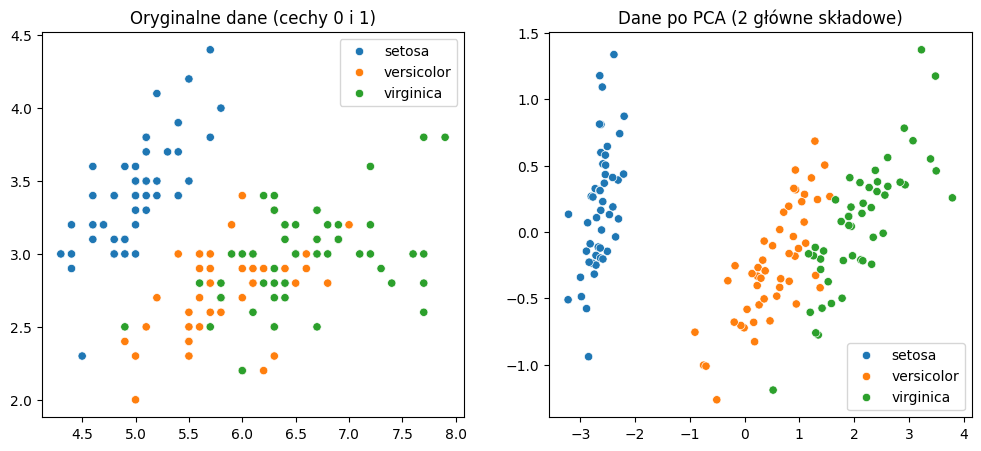

In [22]:
iris = load_iris()
X, y = iris.data, iris.target
labels = iris.target_names

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=[labels[i] for i in y])
plt.title("Oryginalne dane (cechy 0 i 1)")

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.subplot(1, 2, 2)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=[labels[i] for i in y])
plt.title("Dane po PCA (2 główne składowe)")
plt.show()

Zad.2  
Wizualizacja cyfr po PCA (Digits dataset)  
Treść: Sprowadzenie 64-wymiarowych danych obrazów cyfr do 2D, wizualizacja i analiza, jak rozróżnialne są klasy.

In [23]:
from sklearn.datasets import load_digits

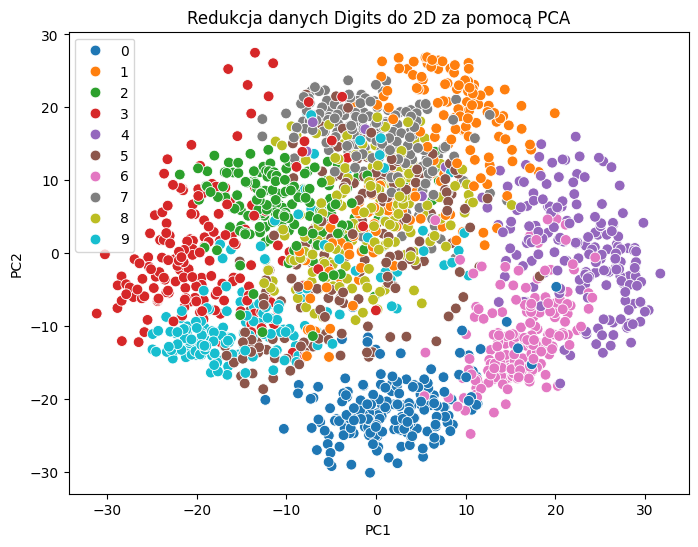

In [24]:
digits = load_digits()
X, y = digits.data, digits.target

pca1 = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='tab10', s=60, legend='full')
plt.title("Redukcja danych Digits do 2D za pomocą PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

Zad.3  
Wizualizacja danych Breast Cancer z PCA  
Treść: Sprawdzenie, czy przypadki złośliwe i łagodne można rozróżnić po redukcji do 2D

In [25]:
from sklearn.datasets import load_breast_cancer

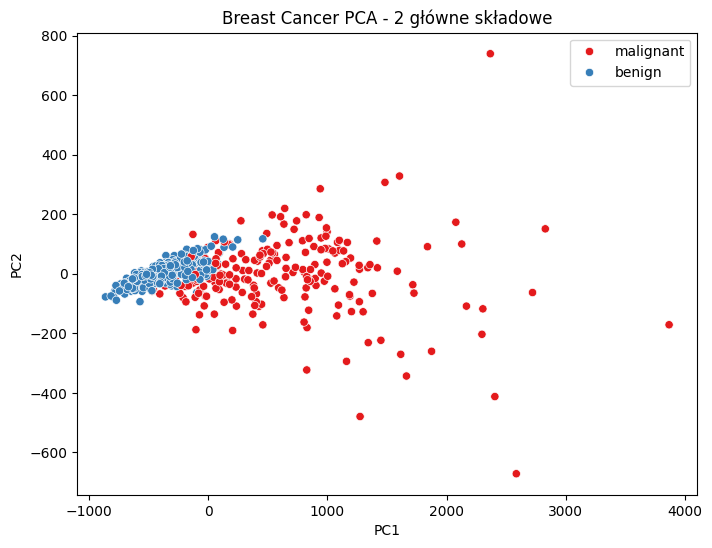

In [26]:
data = load_breast_cancer()
X, y = data.data, data.target
labels = data.target_names

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=[labels[i] for i in y], palette='Set1')
plt.title("Breast Cancer PCA - 2 główne składowe")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

Zad.4  
PCA + klasyfikacja (Digits dataset)  
Treść: Zastosowanie PCA przed klasyfikacją i sprawdzić, jak spada accuracy w zaleźności od liczby głównych składowych.

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

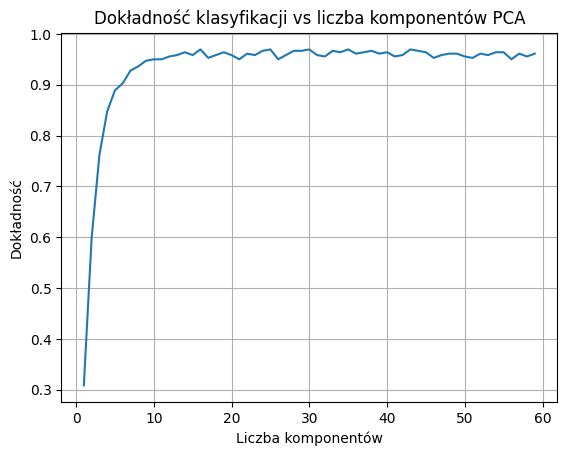

In [34]:
X, y = load_digits(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

components = list(range(1, 60, 1))
accuracy = []

for n in components:
    pca = PCA(n_components=n)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    clf = RandomForestClassifier()
    clf.fit(X_train_pca, y_train)
    y_pred = clf.predict(X_test_pca)

    accuracy.append(accuracy_score(y_test, y_pred))

plt.plot(components, accuracy)
plt.title("Dokładność klasyfikacji vs liczba komponentów PCA")
plt.xlabel("Liczba komponentów")
plt.ylabel("Dokładność")
plt.grid(True)
plt.show()